# Lag-CRP

Temporal contiguity in successive recall transitions, measured as conditional response probability at each lag. The standard lag-CRP shows the tendency to recall items studied near the previously recalled item.

Because the VRT test phase interleaves film cues with recall opportunities, we can also examine how temporal contiguity depends on the cue context surrounding each transition. We compute the lag-CRP under several transition-type masks:

- **All transitions**: No filtering. The standard lag-CRP.
- **Uncued**: Only transitions where the arriving recall had no preceding cue (`cue_clips == 0`). Isolates spontaneous temporal contiguity.
- **Doubly uncued**: Neither the departing nor arriving recall was matched to its cue. The purest measure of spontaneous contiguity with no cue influence on either end.
- **From-cued**: Transitions departing from a recall that matched its preceding cue. Tests compound cueing: if a cue reinstated the temporal context of the matched clip, the next transition should show stronger contiguity.

In [1]:
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jaxcmr.analyses.conditional_crp import plot_crp
from jaxcmr.helpers import find_project_root, load_data
from jaxcmr.selective_interference.analysis import (
    build_transition_masks,
    derive_cue_clips,
)

warnings.filterwarnings("ignore")

In [2]:
run_tag = "VRT_LAG_CRP"
data_path = "data/VRT_clips.h5"
figure_dir = "results/figures"
figure_str = run_tag
max_lag = 5
ylim = None

## Setup and transition masks

We derive `cue_clips` from the interleaved event stream, then build boolean transition-type masks. Each mask is shaped `[n_trials, max_recalls]` and indicates which recall positions should contribute to lag counts. The `plot_crp` function reads `_should_tabulate` from the dataset dict, so we inject the appropriate mask before each call.

When a position is masked out (False), the CRP tabulation still updates its internal state (previous position, availability) but doesn't increment the actual/available lag counters. This ensures correct availability tracking across masked-out transitions.

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)

recalls = np.array(data["recalls"])
cue_clips = derive_cue_clips(
    np.array(data["recall_items"]),
    np.array(data["recall_types"]),
    recalls,
)
tmasks = build_transition_masks(recalls, cue_clips)

task = data["task"]
condition = data["condition"]
intervention = data["intervention"]

# All-True mask for standard (unfiltered) lag-CRP
all_true = jnp.ones_like(data["recalls"], dtype=bool)

print(f"Loaded {recalls.shape[0]} trials")
for name, mask in tmasks.items():
    n = int(mask.sum())
    print(f"  {name}: {n} positions")


def trial_mask(mask):
    return jnp.asarray(mask).reshape(-1)


def summarize_masks(labels, masks):
    for label, mask in zip(labels, masks):
        n_trials = int(jnp.sum(mask))
        n_subjects = int(jnp.unique(data["subject"][mask]).size)
        print(f"{label}: trials={n_trials}, subjects={n_subjects}")


def make_data(should_tabulate):
    """Return data dict with _should_tabulate injected."""
    return {**data, "_should_tabulate": jnp.array(should_tabulate)}


def plot_contrast(masks, labels, contrast_name, should_tab, axis=None, suffix=None):
    d = make_data(should_tab)
    plot_crp(
        datasets=[d] * len(masks),
        trial_masks=masks,
        max_lag=max_lag,
        labels=labels,
        contrast_name=contrast_name,
        axis=axis,
    )
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    if axis is None:
        save_figure(figure_dir, figure_str, suffix=suffix or contrast_name)


def save_figure(fig_dir, fig_str, suffix=None):
    if not fig_str:
        plt.show()
        return
    os.makedirs(fig_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    path = os.path.join(fig_dir, f"{fig_str}{suffix_str}.png")
    plt.savefig(path, bbox_inches="tight", dpi=600)
    plt.show()

Loaded 240 trials
  uncued: 897 positions
  cue_matched: 891 positions
  doubly_uncued: 744 positions
  from_cued: 771 positions


## All transitions

Standard lag-CRP with no transition-type filtering. All valid recall transitions contribute.

Involuntary: trials=120, subjects=120
Voluntary: trials=120, subjects=120


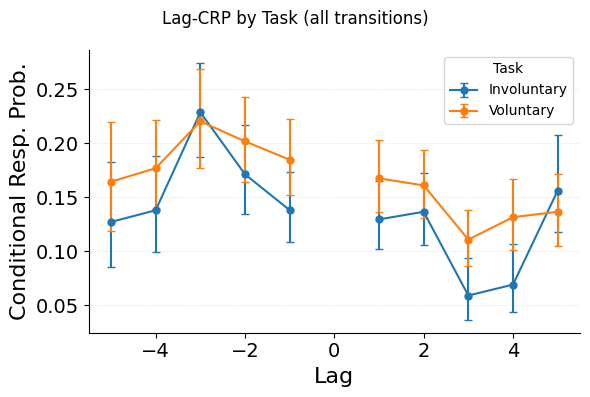

In [4]:
labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", all_true, axis=ax)
fig.suptitle("Lag-CRP by Task (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_task")

Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


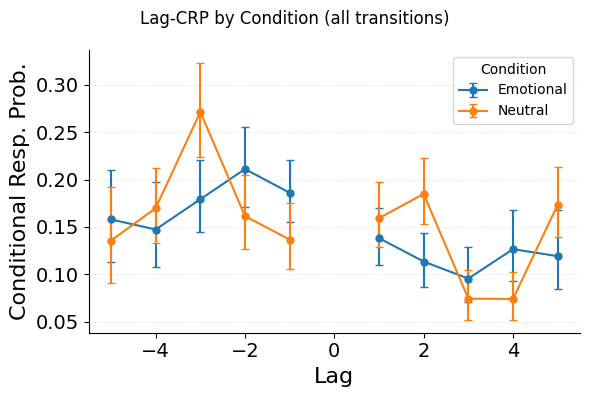

In [5]:
labels = ["Emotional", "Neutral"]
masks = [trial_mask(condition == 1), trial_mask(condition == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", all_true, axis=ax)
fig.suptitle("Lag-CRP by Condition (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_condition")

Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


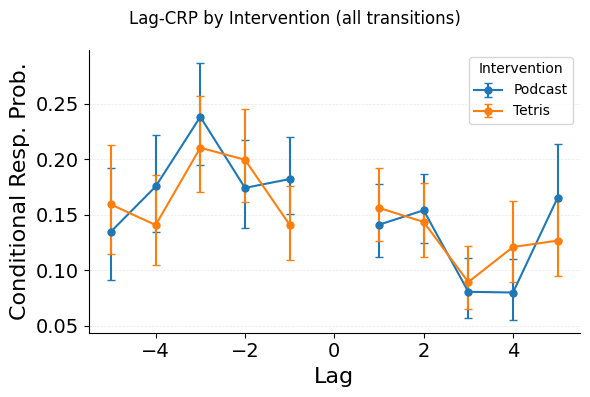

In [6]:
labels = ["Podcast", "Tetris"]
masks = [trial_mask(intervention == 0), trial_mask(intervention == 1)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", all_true, axis=ax)
fig.suptitle("Lag-CRP by Intervention (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_intervention")

Invol+Emotional: trials=60, subjects=60
Invol+Neutral: trials=60, subjects=60


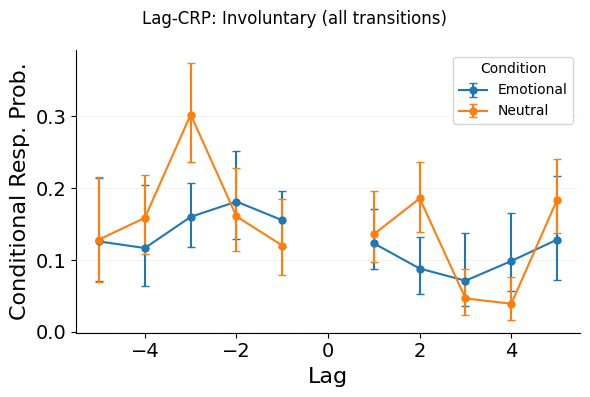

Vol+Emotional: trials=60, subjects=60
Vol+Neutral: trials=60, subjects=60


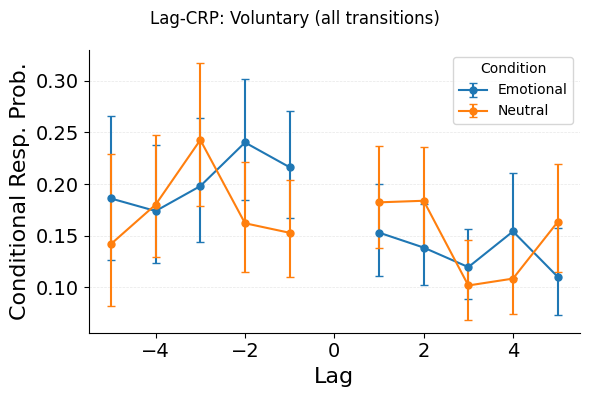

Involuntary+Emot: trials=60, subjects=60
Voluntary+Emot: trials=60, subjects=60


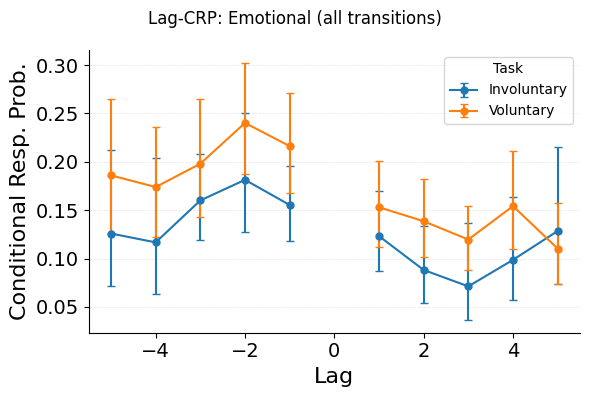

Involuntary+Neut: trials=60, subjects=60
Voluntary+Neut: trials=60, subjects=60


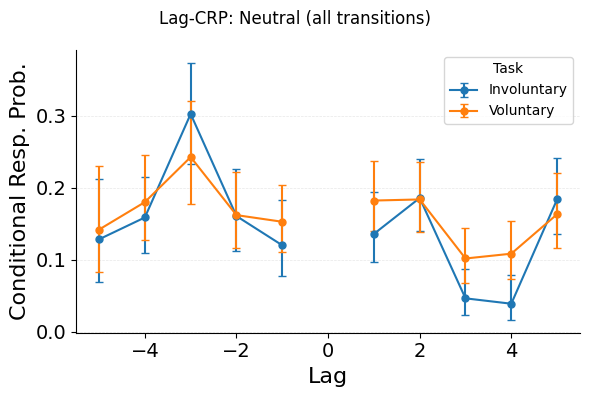

In [7]:
# Condition within Task

labels = ["Emotional", "Neutral"]

masks = [
    trial_mask((task == 1) & (condition == 1)),
    trial_mask((task == 1) & (condition == 2)),
]
summarize_masks([f"Invol+{l}" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", all_true, axis=ax)
fig.suptitle("Lag-CRP: Involuntary (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_invol_condition")

masks = [
    trial_mask((task == 2) & (condition == 1)),
    trial_mask((task == 2) & (condition == 2)),
]
summarize_masks([f"Vol+{l}" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", all_true, axis=ax)
fig.suptitle("Lag-CRP: Voluntary (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_vol_condition")

# Task within Condition

labels = ["Involuntary", "Voluntary"]

masks = [
    trial_mask((task == 1) & (condition == 1)),
    trial_mask((task == 2) & (condition == 1)),
]
summarize_masks([f"{l}+Emot" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", all_true, axis=ax)
fig.suptitle("Lag-CRP: Emotional (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_emot_task")

masks = [
    trial_mask((task == 1) & (condition == 2)),
    trial_mask((task == 2) & (condition == 2)),
]
summarize_masks([f"{l}+Neut" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", all_true, axis=ax)
fig.suptitle("Lag-CRP: Neutral (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_neut_task")

Invol+Podcast: trials=60, subjects=60
Invol+Tetris: trials=60, subjects=60


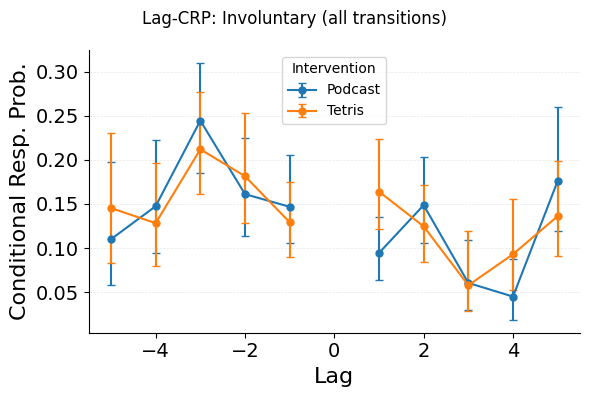

Vol+Podcast: trials=60, subjects=60
Vol+Tetris: trials=60, subjects=60


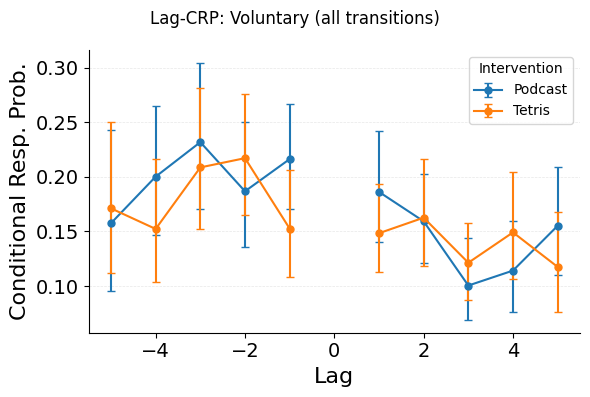

Involuntary+Podcast: trials=60, subjects=60
Voluntary+Podcast: trials=60, subjects=60


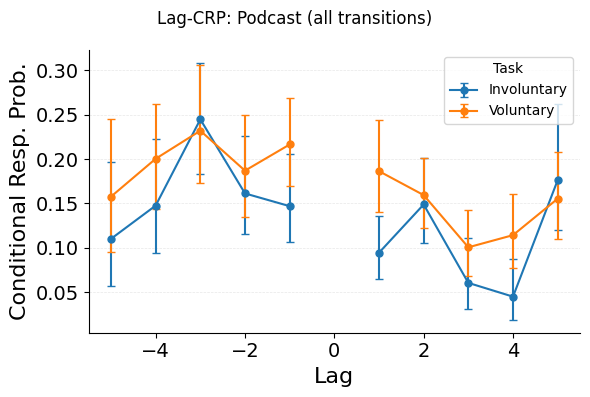

Involuntary+Tetris: trials=60, subjects=60
Voluntary+Tetris: trials=60, subjects=60


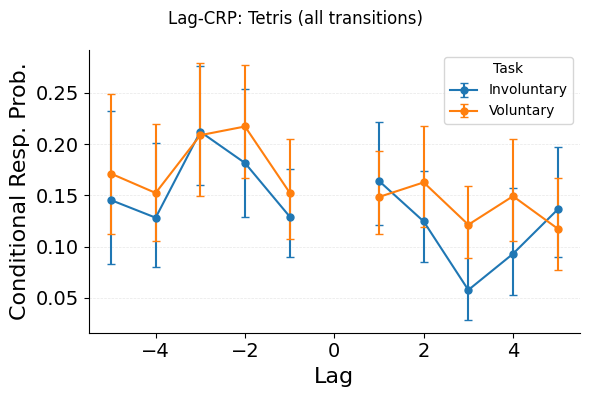

In [8]:
# Intervention within Task

labels = ["Podcast", "Tetris"]

masks = [
    trial_mask((task == 1) & (intervention == 0)),
    trial_mask((task == 1) & (intervention == 1)),
]
summarize_masks([f"Invol+{l}" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", all_true, axis=ax)
fig.suptitle("Lag-CRP: Involuntary (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_invol_intervention")

masks = [
    trial_mask((task == 2) & (intervention == 0)),
    trial_mask((task == 2) & (intervention == 1)),
]
summarize_masks([f"Vol+{l}" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", all_true, axis=ax)
fig.suptitle("Lag-CRP: Voluntary (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_vol_intervention")

# Task within Intervention

labels = ["Involuntary", "Voluntary"]

masks = [
    trial_mask((task == 1) & (intervention == 0)),
    trial_mask((task == 2) & (intervention == 0)),
]
summarize_masks([f"{l}+Podcast" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", all_true, axis=ax)
fig.suptitle("Lag-CRP: Podcast (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_podcast_task")

masks = [
    trial_mask((task == 1) & (intervention == 1)),
    trial_mask((task == 2) & (intervention == 1)),
]
summarize_masks([f"{l}+Tetris" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", all_true, axis=ax)
fig.suptitle("Lag-CRP: Tetris (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_tetris_task")

Emot+Podcast: trials=60, subjects=60
Emot+Tetris: trials=60, subjects=60


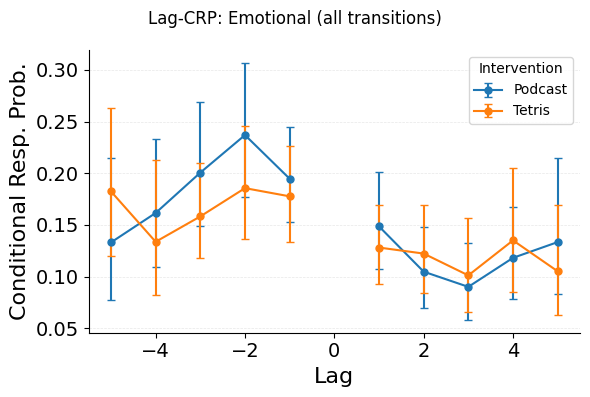

Neut+Podcast: trials=60, subjects=60
Neut+Tetris: trials=60, subjects=60


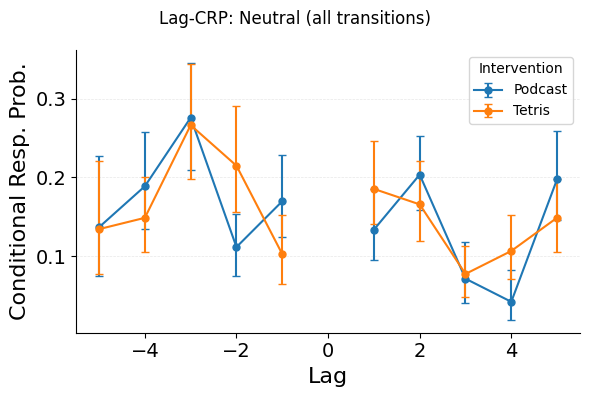

Emotional+Podcast: trials=60, subjects=60
Neutral+Podcast: trials=60, subjects=60


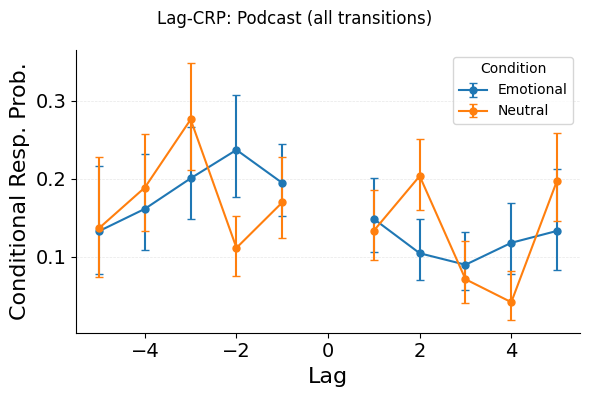

Emotional+Tetris: trials=60, subjects=60
Neutral+Tetris: trials=60, subjects=60


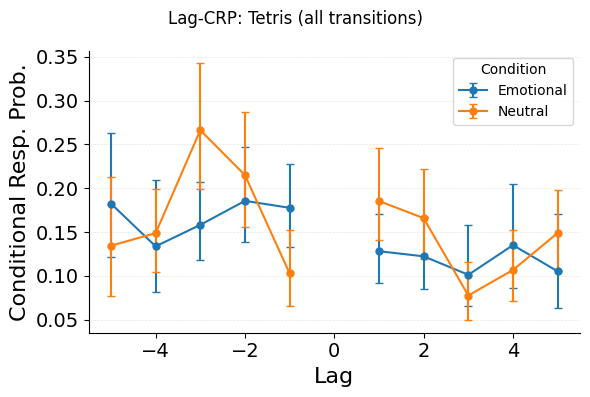

In [9]:
# Intervention within Condition

labels = ["Podcast", "Tetris"]

masks = [
    trial_mask((condition == 1) & (intervention == 0)),
    trial_mask((condition == 1) & (intervention == 1)),
]
summarize_masks([f"Emot+{l}" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", all_true, axis=ax)
fig.suptitle("Lag-CRP: Emotional (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_emot_intervention")

masks = [
    trial_mask((condition == 2) & (intervention == 0)),
    trial_mask((condition == 2) & (intervention == 1)),
]
summarize_masks([f"Neut+{l}" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", all_true, axis=ax)
fig.suptitle("Lag-CRP: Neutral (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_neut_intervention")

# Condition within Intervention

labels = ["Emotional", "Neutral"]

masks = [
    trial_mask((condition == 1) & (intervention == 0)),
    trial_mask((condition == 2) & (intervention == 0)),
]
summarize_masks([f"{l}+Podcast" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", all_true, axis=ax)
fig.suptitle("Lag-CRP: Podcast (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_podcast_condition")

masks = [
    trial_mask((condition == 1) & (intervention == 1)),
    trial_mask((condition == 2) & (intervention == 1)),
]
summarize_masks([f"{l}+Tetris" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", all_true, axis=ax)
fig.suptitle("Lag-CRP: Tetris (all transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="all_tetris_condition")

## Uncued transitions

Only transitions where the arriving recall had no preceding cue. This isolates spontaneous temporal contiguity from cue-driven transitions.

Involuntary: trials=120, subjects=120
Voluntary: trials=120, subjects=120


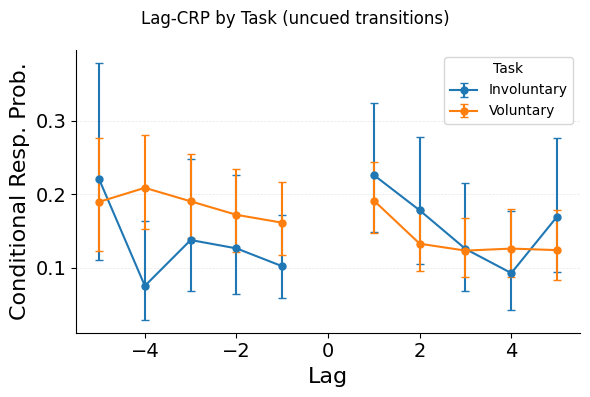

In [10]:
uncued = tmasks["uncued"]

labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", uncued, axis=ax)
fig.suptitle("Lag-CRP by Task (uncued transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="uncued_task")

Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


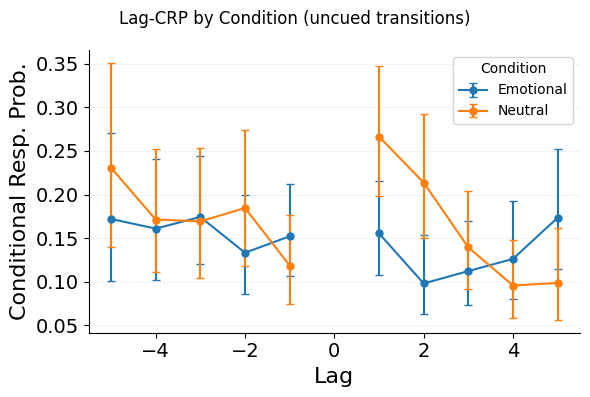

In [11]:
labels = ["Emotional", "Neutral"]
masks = [trial_mask(condition == 1), trial_mask(condition == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", uncued, axis=ax)
fig.suptitle("Lag-CRP by Condition (uncued transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="uncued_condition")

Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


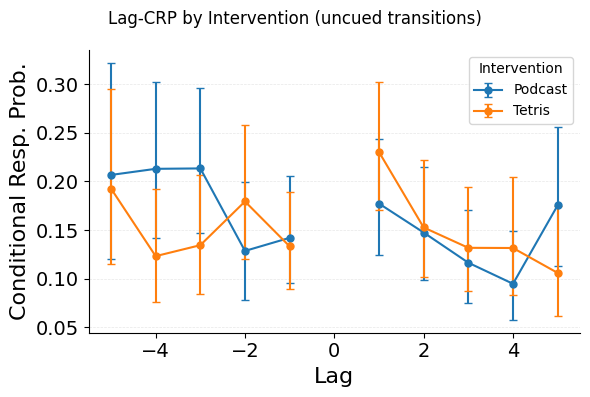

In [12]:
labels = ["Podcast", "Tetris"]
masks = [trial_mask(intervention == 0), trial_mask(intervention == 1)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", uncued, axis=ax)
fig.suptitle("Lag-CRP by Intervention (uncued transitions)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="uncued_intervention")

Involuntary+Emot: trials=60, subjects=60
Voluntary+Emot: trials=60, subjects=60


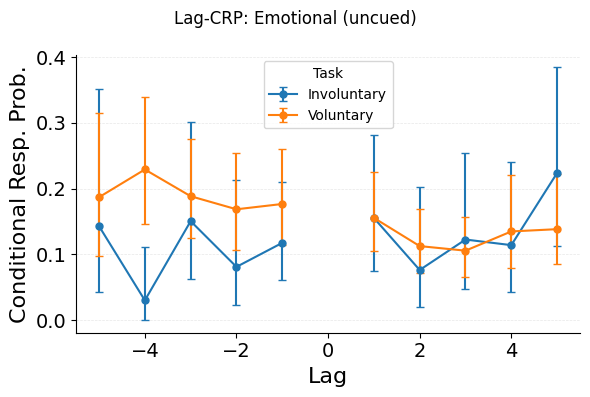

Involuntary+Neut: trials=60, subjects=60
Voluntary+Neut: trials=60, subjects=60


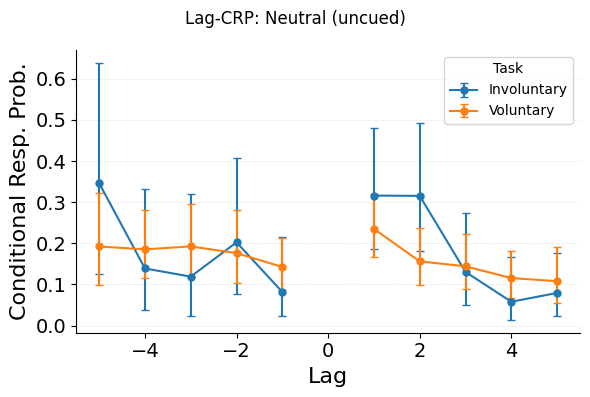

In [13]:
# Task within Condition (uncued)

labels = ["Involuntary", "Voluntary"]

masks = [
    trial_mask((task == 1) & (condition == 1)),
    trial_mask((task == 2) & (condition == 1)),
]
summarize_masks([f"{l}+Emot" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", uncued, axis=ax)
fig.suptitle("Lag-CRP: Emotional (uncued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="uncued_emot_task")

masks = [
    trial_mask((task == 1) & (condition == 2)),
    trial_mask((task == 2) & (condition == 2)),
]
summarize_masks([f"{l}+Neut" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", uncued, axis=ax)
fig.suptitle("Lag-CRP: Neutral (uncued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="uncued_neut_task")

## Doubly uncued transitions

Neither the departing nor arriving recall was matched to its preceding cue. This is the purest measure of spontaneous temporal contiguity, with no cue influence on either side of the transition.

Involuntary: trials=120, subjects=120
Voluntary: trials=120, subjects=120


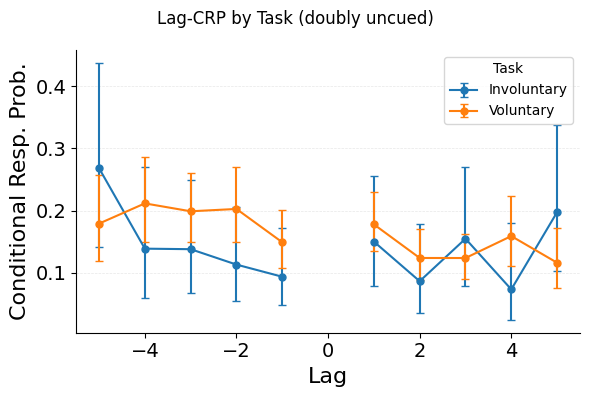

In [14]:
doubly_uncued = tmasks["doubly_uncued"]

labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", doubly_uncued, axis=ax)
fig.suptitle("Lag-CRP by Task (doubly uncued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="doubly_uncued_task")

Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


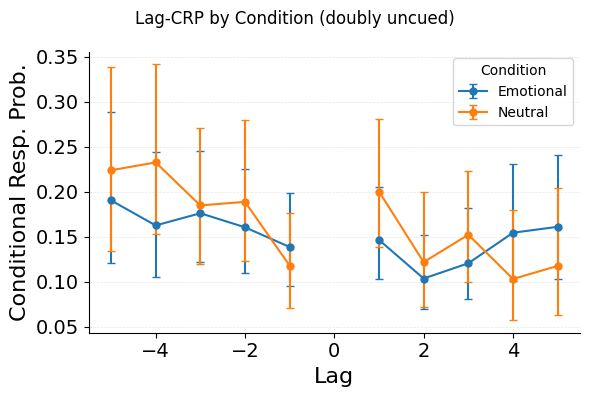

In [15]:
labels = ["Emotional", "Neutral"]
masks = [trial_mask(condition == 1), trial_mask(condition == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", doubly_uncued, axis=ax)
fig.suptitle("Lag-CRP by Condition (doubly uncued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="doubly_uncued_condition")

Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


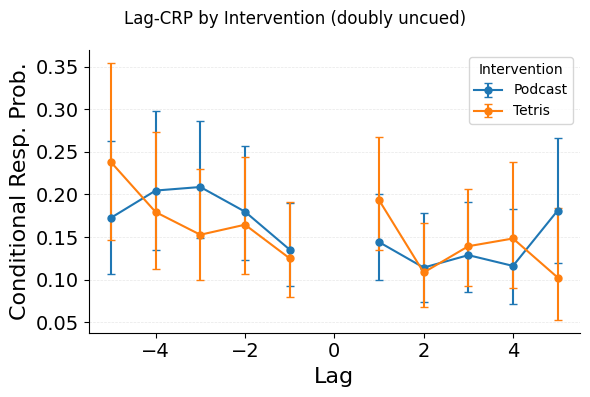

In [16]:
labels = ["Podcast", "Tetris"]
masks = [trial_mask(intervention == 0), trial_mask(intervention == 1)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", doubly_uncued, axis=ax)
fig.suptitle("Lag-CRP by Intervention (doubly uncued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="doubly_uncued_intervention")

## From-cued transitions (compound cueing test)

Transitions where the departing recall matched its preceding cue. If the cue successfully reinstated the temporal context of the matched clip, subsequent transitions should show stronger contiguity (relative to the departing recall's study position) compared to transitions from uncued recalls.

Involuntary: trials=120, subjects=120
Voluntary: trials=120, subjects=120


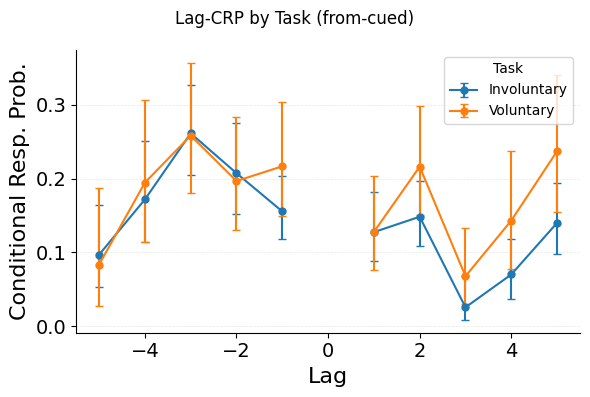

In [17]:
from_cued = tmasks["from_cued"]

labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", from_cued, axis=ax)
fig.suptitle("Lag-CRP by Task (from-cued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="from_cued_task")

Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


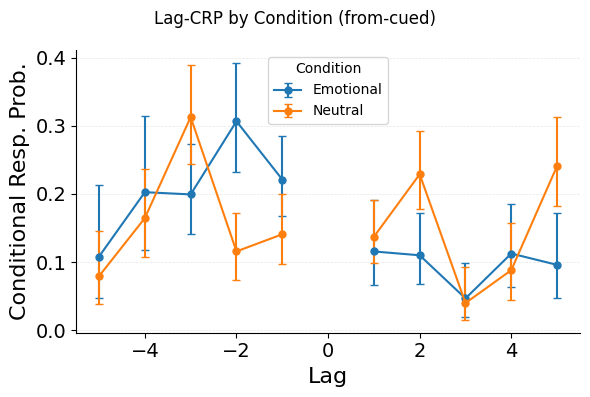

In [18]:
labels = ["Emotional", "Neutral"]
masks = [trial_mask(condition == 1), trial_mask(condition == 2)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Condition", from_cued, axis=ax)
fig.suptitle("Lag-CRP by Condition (from-cued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="from_cued_condition")

Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


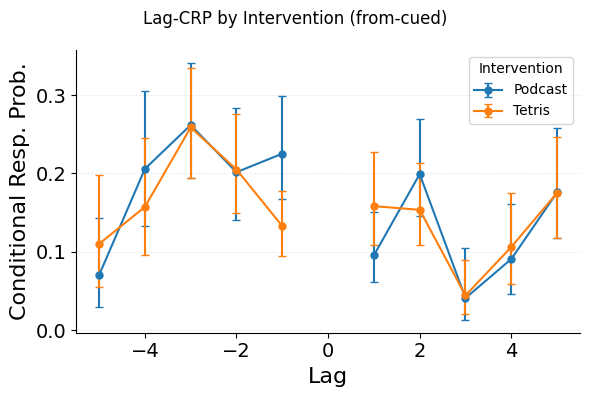

In [19]:
labels = ["Podcast", "Tetris"]
masks = [trial_mask(intervention == 0), trial_mask(intervention == 1)]
summarize_masks(labels, masks)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Intervention", from_cued, axis=ax)
fig.suptitle("Lag-CRP by Intervention (from-cued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="from_cued_intervention")

Involuntary+Emot: trials=60, subjects=60
Voluntary+Emot: trials=60, subjects=60


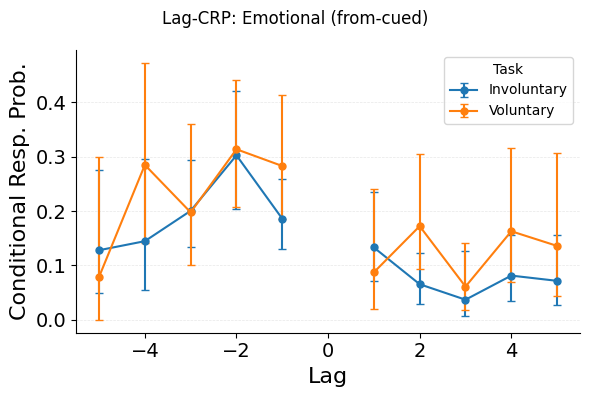

Involuntary+Neut: trials=60, subjects=60
Voluntary+Neut: trials=60, subjects=60


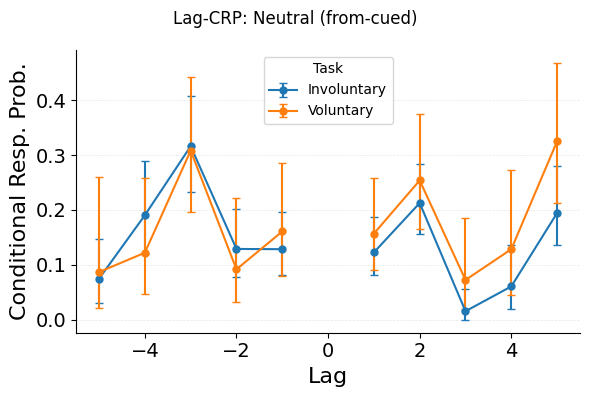

In [20]:
# Task within Condition (from-cued)

labels = ["Involuntary", "Voluntary"]

masks = [
    trial_mask((task == 1) & (condition == 1)),
    trial_mask((task == 2) & (condition == 1)),
]
summarize_masks([f"{l}+Emot" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", from_cued, axis=ax)
fig.suptitle("Lag-CRP: Emotional (from-cued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="from_cued_emot_task")

masks = [
    trial_mask((task == 1) & (condition == 2)),
    trial_mask((task == 2) & (condition == 2)),
]
summarize_masks([f"{l}+Neut" for l in labels], masks)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_contrast(masks, labels, "Task", from_cued, axis=ax)
fig.suptitle("Lag-CRP: Neutral (from-cued)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="from_cued_neut_task")